# 02 · Exploratory Data Analysis (EDA)

**Goal.** Understand the modelling table before any forecasting model is
built: distributions, trends, missingness, correlations and the policy
events that shaped UK wheat yields.

**Input.** `data/processed/uk_wheat_modelling_table_1980_2024.csv`
(produced by stage 03).

**Output.** Charts shown inline below (no image files are saved).

Every plot below is generated by the code cell that precedes it — nothing is
pre-rendered, so rerunning this notebook regenerates everything.

## 2.1 Setup & data load

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from src._bootstrap import init_script, common_imports

c = common_imports()
display = init_script()

from src import plotting  # noqa: F401  (inline in notebooks, Agg when headless)


def load_data():
    """Load the modelling table and print a summary."""
    from src._bootstrap import load_modelling_table

    data = load_modelling_table()
    print(
        f"Modelling table: {data.shape[0]} rows x {data.shape[1]} cols "
        f"({data['year'].min()}-{data['year'].max()})"
    )
    return data

Modelling table: 45 rows x 13 cols (1980-2024)


,year,yield_t_ha,autumn_temp,autumn_rain,winter_temp,winter_rain,spring_temp,spring_rain,grainfill_temp,grainfill_rain,cap_1992,cap_2005,ukraine_2022
0,1980,5.880,9.90,231.3,3.78,345.3,8.57,237.7,16.39,201.2,0,0,0
1,1981,5.840,9.42,157.1,4.06,283.9,9.21,122.6,14.31,237.5,0,0,0
2,1982,6.200,10.08,146.5,5.61,215.3,8.07,226.5,14.75,182.9,0,0,0
3,1983,6.370,10.81,224.1,4.92,237.1,8.36,180.4,15.79,217.8,0,0,0
4,1984,7.714,9.43,188.8,2.83,320.8,8.35,140.7,13.96,192.8,0,0,0


## 2.2 Data quality

No missing values and no duplicate years is the first thing to confirm.

In [2]:
def check_data_quality(data):
    """Inspect missing values, dtypes, and duplicates."""
    quality = c.pd.DataFrame(
        {
            "column": data.columns,
            "dtype": data.dtypes.astype(str).values,
            "n_nonnull": data.notna().sum().values,
            "n_missing": data.isna().sum().values,
            "unique": data.nunique().values,
        }
    )
    display(quality)
    print(f"Total missing values: {int(data.isna().sum().sum())}")
    print(f"Duplicate years: {int(data['year'].duplicated().sum())}")

,column,dtype,n_nonnull,n_missing,unique
0,year,int64,45,0,45
1,yield_t_ha,float64,45,0,43
2,autumn_temp,float64,45,0,41
3,autumn_rain,float64,45,0,44
4,winter_temp,float64,45,0,45
5,winter_rain,float64,45,0,45
6,spring_temp,float64,45,0,40
7,spring_rain,float64,45,0,44
8,grainfill_temp,float64,45,0,42
9,grainfill_rain,float64,45,0,44


## 2.3 Target distribution — UK wheat yield (t/ha)

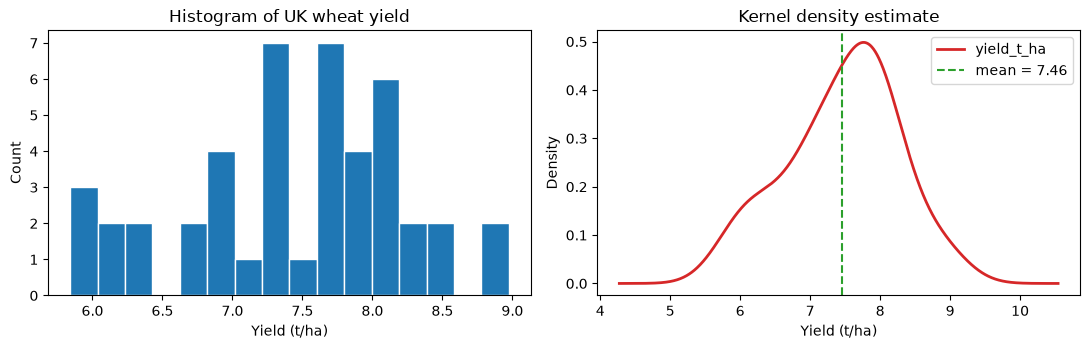

In [4]:
def plot_target_distribution(data):
    """Histogram + KDE of wheat yields."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

    axes[0].hist(data["yield_t_ha"], bins=16, color="#1f77b4", edgecolor="white")
    axes[0].set_xlabel("Yield (t/ha)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Histogram of UK wheat yield")

    data["yield_t_ha"].plot.kde(ax=axes[1], color="#d62728", linewidth=2)
    axes[1].axvline(
        data["yield_t_ha"].mean(),
        color="#2ca02c",
        linestyle="--",
        label=f"mean = {data['yield_t_ha'].mean():.2f}",
    )
    axes[1].set_xlabel("Yield (t/ha)")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Kernel density estimate")
    axes[1].legend()

    fig.tight_layout()
    plt.show()


def yield_summary(data):
    """Descriptive statistics of the target variable."""
    return data["yield_t_ha"].describe().to_frame("UK wheat yield (t/ha)")

## 2.4 The yield time series (1980–2024)

A clear upward trend dominates, with notable dips. We annotate the events
that the modelling table encodes as dummy variables.

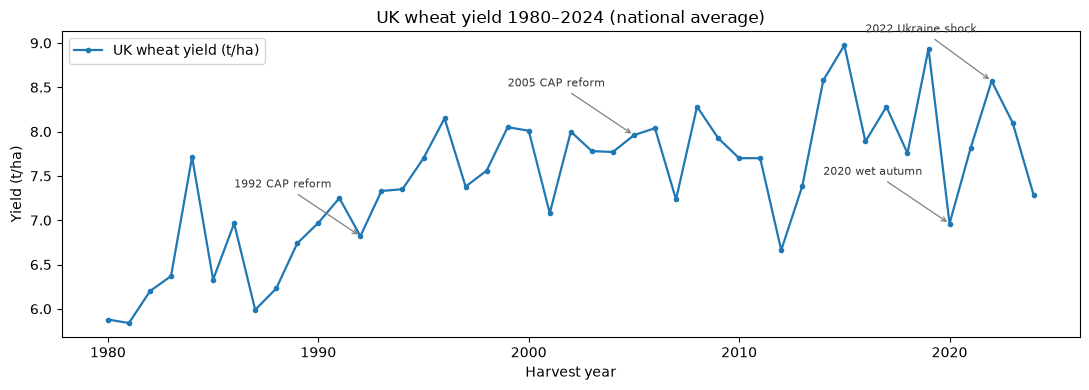

In [6]:
_ANNOTATIONS = {
    1992: "1992 CAP reform",
    2005: "2005 CAP reform",
    2020: "2020 wet autumn",
    2022: "2022 Ukraine shock",
}


def plot_yield_timeseries(data):
    """Yield over time with policy-event annotations."""
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(
        data["year"],
        data["yield_t_ha"],
        marker="o",
        markersize=3,
        linewidth=1.6,
        color="#1f77b4",
        label="UK wheat yield (t/ha)",
    )

    for year, label in _ANNOTATIONS.items():
        row = data[data["year"] == year]
        if len(row):
            ax.annotate(
                label,
                (year, row["yield_t_ha"].iloc[0]),
                xytext=(year - 6, row["yield_t_ha"].iloc[0] + 0.55),
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.9),
                fontsize=8,
                color="#333333",
            )

    ax.set_xlabel("Harvest year")
    ax.set_ylabel("Yield (t/ha)")
    ax.set_title("UK wheat yield 1980–2024 (national average)")
    ax.legend()
    fig.tight_layout()
    plt.show()

**Non-stationarity evidence.** The series is not stationary — the mean drifts
up from ~6.4 t/ha in the 1980s to ~8 t/ha in the 2010s. (This is a gradual
trend, not an abrupt regime shift — the policy dummies below are one-year
pulses, not steps.) This motivates:

* differencing / stochastic trends in the ARIMA-style models;
* the **expanding-window** evaluation protocol (the training mean is not a
  valid forecast of a level-shifting target);
* trend-aware baselines in stage 05.

In [7]:
def decade_stats(data):
    """Yield statistics grouped by decade."""
    d = data.assign(decade=(data["year"] // 10) * 10)
    by_decade = d.groupby("decade")["yield_t_ha"].agg(["mean", "std", "min", "max"])
    return by_decade.round(3)

,mean,std,min,max
decade,,,,
1980,6.426,0.576,5.840,7.714
1990,7.456,0.424,6.820,8.150
2000,7.808,0.373,7.080,8.281
2010,7.986,0.719,6.663,8.975
2020,7.745,0.640,6.962,8.571


## 2.5 Weather covariates over time

Temperature and rainfall across the four phenological windows
(autumn, winter, spring, grain fill).

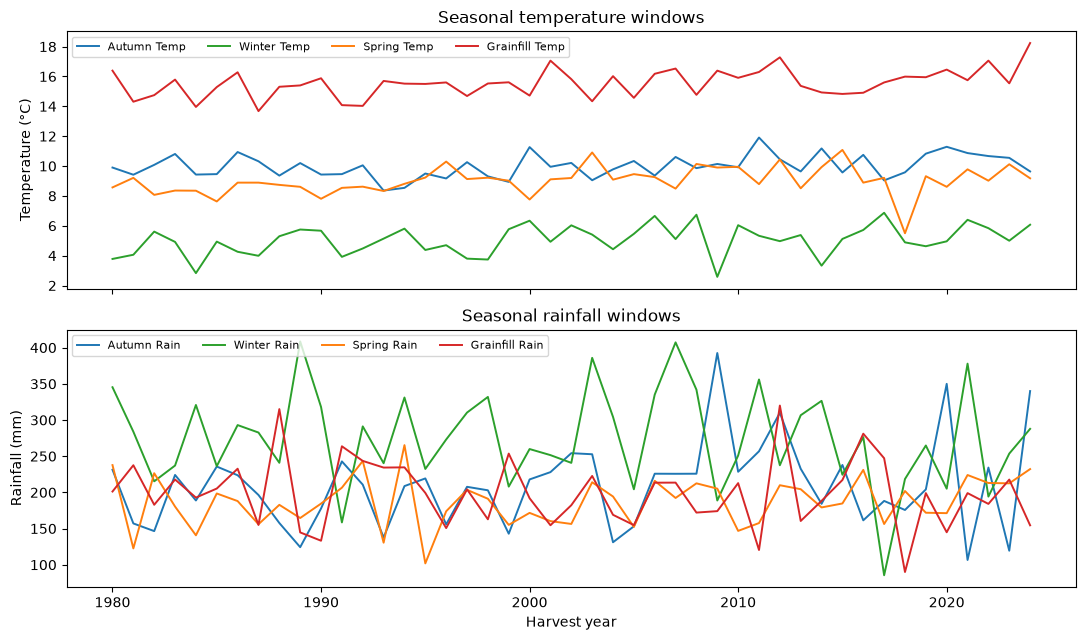

In [8]:
TEMP_COLS = ["autumn_temp", "winter_temp", "spring_temp", "grainfill_temp"]
RAIN_COLS = ["autumn_rain", "winter_rain", "spring_rain", "grainfill_rain"]
_PAL = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]


def plot_weather_covariates(data):
    """Seasonal temperature and rainfall over time."""
    fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
    for col, color in zip(TEMP_COLS, _PAL):
        axes[0].plot(
            data["year"],
            data[col],
            label=col.replace("_", " ").title(),
            color=color,
            linewidth=1.4,
        )
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].set_title("Seasonal temperature windows")
    axes[0].legend(ncol=4, fontsize=8)

    for col, color in zip(RAIN_COLS, _PAL):
        axes[1].plot(
            data["year"],
            data[col],
            label=col.replace("_", " ").title(),
            color=color,
            linewidth=1.4,
        )
    axes[1].set_ylabel("Rainfall (mm)")
    axes[1].set_xlabel("Harvest year")
    axes[1].set_title("Seasonal rainfall windows")
    axes[1].legend(ncol=4, fontsize=8)

    fig.tight_layout()
    plt.show()

## 2.6 Correlations with yield

Which covariates move with yield? A full correlation heatmap, followed by a
ranked bar of each covariate's correlation with the target.

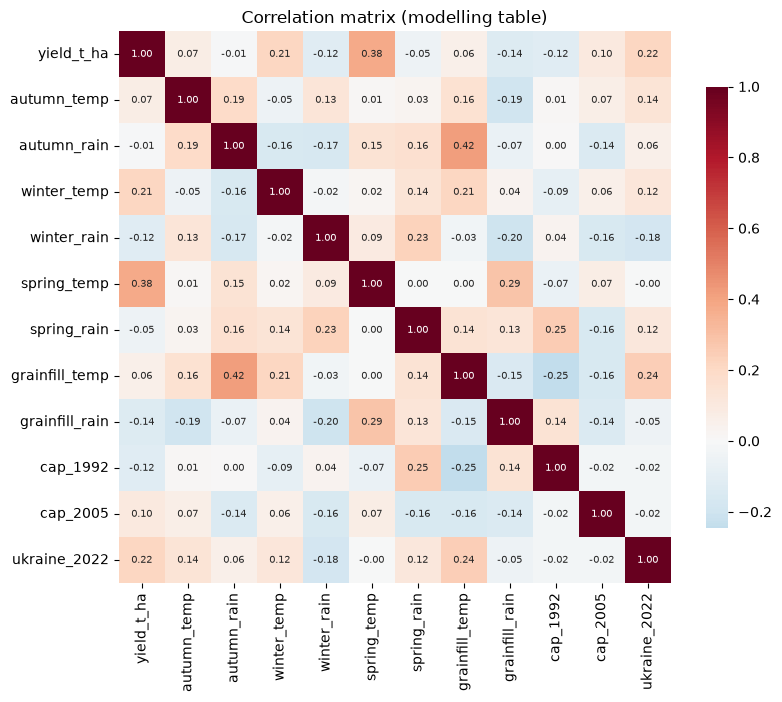

In [9]:
def plot_correlations(data):
    """Correlation heatmap of the modelling table + ranked bar of covariates vs yield."""
    cov_cols = [c for c in data.columns if c not in ("year", "yield_t_ha", "decade")]
    fig, ax = plt.subplots(figsize=(8.5, 7))
    sns.heatmap(
        data[["yield_t_ha"] + cov_cols].corr(),
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        square=True,
        ax=ax,
        annot_kws={"size": 7},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title("Correlation matrix (modelling table)")
    fig.tight_layout()
    plt.show()

    corr_with_yield = data[cov_cols].corrwith(data["yield_t_ha"]).sort_values()
    fig, ax = plt.subplots(figsize=(9, 3.6))
    colors = ["#2ca02c" if v > 0 else "#d62728" for v in corr_with_yield.values]
    corr_with_yield.plot.barh(ax=ax, color=colors)
    ax.set_xlabel("Correlation with yield (t/ha)")
    ax.set_title("Covariates ranked by correlation with UK wheat yield")
    ax.axvline(0, color="black", linewidth=0.8)
    fig.tight_layout()
    plt.show()

    return corr_with_yield.to_frame("corr_with_yield").round(3)

### Key EDA findings

1. **Strong upward trend** in yield — forecasting must account for a
   non-stationary target (differencing, trend-aware baselines).
2. **Linear correlations are weak overall** (all |r| < 0.38). The strongest
   signal is `spring_temp` (r = 0.378, warm springs help); the rainfall
   windows are consistently weak and slightly *negative* (r from −0.01 to
   −0.14), i.e. wetter years tend to be marginally poorer — but no single
   covariate moves yield on its own. Correlations are computed on the raw
   (trending) series, so part of each association reflects shared time
   trends rather than pure year-to-year agronomy.
3. **Policy dummies** (`cap_1992`, `cap_2005`, `ukraine_2022`) are one-year
   **pulse** indicators (1 in the event year, 0 elsewhere) for transient
   shocks — the CAP-reform years and the 2022 Ukraine invasion. They are not
   step changes: a pulse cannot encode a lasting regime shift, so the
   persistent drift is left to differencing and trend-aware baselines.
4. **No missing data, no duplicates** — the table is clean and ready for
   feature engineering and modelling.

These observations directly shape the modelling choices in stages 04–05.

## Run

In [ ]:
def main():
    """Run the full EDA pipeline."""
    data = load_data()
    print()
    check_data_quality(data)
    print()
    plot_target_distribution(data)
    display(yield_summary(data))
    print()
    plot_yield_timeseries(data)
    display(decade_stats(data))
    print()
    plot_weather_covariates(data)
    display(plot_correlations(data))

In [ ]:
if __name__ == "__main__":
    main()